# Tsanfleuron Project (2019-2020)

In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# import from package 'geone'
from geone import img
import geone.imgplot as imgplt
import geone.customcolors as ccol
import geone.deesseinterface as dsi

import pickle
import time

### MPS simulation

#### Test MPS clear zone

In [36]:
newImg = img.Img(nx=nx, ny=ny, nz=nz, 
                ox=ox, oy=oy, oz=oz,
                sx=sx, sy=sy, sz=sz,nv=1,
                 v=[array of value], varname='mnt'
            )

SyntaxError: invalid syntax (<ipython-input-36-6e06119da391>, line 4)

#### MPS glacier

In [37]:
#Load the data
with open('datas/TI/pickle/ti_alt1_alti3d.pickle', 'br') as file:
    ti_alt2 = pickle.load(file)
with open('datas/Masks/pickle/glacier_mask_2m.pickle', 'br') as file:
    mask_2m = pickle.load(file)
with open('datas/PointSet/pickle/hd_GPR.pickle', 'br') as file:
    hd_GPR = pickle.load(file)
with open('datas/PointSet/pickle/hd_MNT.pickle', 'br') as file:
    hd_MNT = pickle.load(file)
with open('datas/DEM/pickle/dsm_alt3d_2m.pickle', 'br') as file:
    dem_2m = pickle.load(file)

In [38]:
hd_GPR

In [39]:
#Check if ti varname == hd_varname
#If not modify the varname of the TI with: ti_alt2.varname='bedRock'
ti_alt2.varname, hd_GPR.varname, hd_MNT.varname

(['alt'], ['X', 'Y', 'Z', 'bedRock'], ['X', 'Y', 'Z', 'bedRock'])

In [40]:
#The mask value need to be only 0 and 1
#We have to replace the nan value to 0 value
mask_2m.val[mask_2m.val[:,:,:,:]!=1]=0

In [41]:
#DeeSse input parameters, with relative distance flag active:
deesse_input = dsi.DeesseInput(
    nx=mask_2m.nx, ny=mask_2m.ny, nz=1,     # dimension of the simulation grid (number of cells)
    sx=mask_2m.sx, sy=mask_2m.sy, sz=1.0,   # cells units in the simulation grid (here are the default values)
    ox=mask_2m.ox, oy=mask_2m.oy, oz=0.0,   # origin of the simulation grid (here are the default values)
    nv=1, varname='bedRock',     # number of variable(s), name of the variable(s)
    nTI=1, TI=ti_alt2,             # number of TI(s), TI (class dsi.Img)
    mask=mask_2m.val,
    dataPointSet=[hd_GPR,hd_MNT],          # hard data
    relativeDistanceFlag=True,
    distanceType=1,           # distance type: proportion of mismatching nodes (categorical var., default)
    nneighboringNode=12,      # max. number of neighbors (for the patterns)
    distanceThreshold=0.05,   # acceptation threshold (for distance between patterns)
    maxScanFraction=0.25,     # max. scanned fraction of the TI (for simulation of each cell)
    npostProcessingPathMax=1, # number of post-processing path(s)
    seed=444,                 # seed (initialization of the random number generator)
    nrealization=10) 

In [43]:
#We run the deeSse simulation and store the output to the variable sim
#If n realization >=1 sim[0] the first simulation, sim[1] the second one ...
deesse_output = dsi.deesseRun(deesse_input)
sim = deesse_output['sim']

********************************************************************************
DEESSE VERSION 3.2 / BUILD NUMBER 20200213
********************************************************************************
ERROR 99998: NO VALID LICENSE FOUND - DEESSE CAN BE RUN ONLY WITH SMALL SIMULATION GRID (max. 2500 cells)


TypeError: 'NoneType' object is not subscriptable

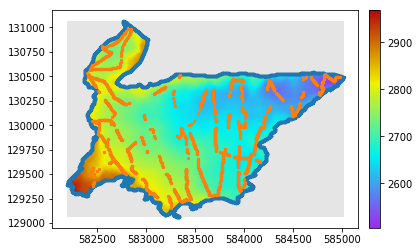

In [89]:
#We plot the realisation 0, with the point set location
imgplt.drawImage2D(sim[0])
plt.scatter(hd_MNT.x(),hd_MNT.y(),s=5)
plt.scatter(hd_GPR.x(),hd_GPR.y(),s=5)

In [189]:
#Some statistics on the n realizations
all_sim     = img.gatherImages(sim) # all_sim is now one image with nreal variables
all_sim_me  = img.imageContStat(all_sim, 'mean') # do statistics (pixel-wise mean)
all_sim_std = img.imageContStat(all_sim, 'std')  # do statistics (pixel-wise standard deviation)

/home/valentin/anaconda3/lib/python3.7/site-packages/geone/img.py:1554: RuntimeWarning: Mean of empty slice
  imOut.append_var(func(im.val.reshape(im.nv,-1), axis=0, **kwargs))
/home/valentin/anaconda3/lib/python3.7/site-packages/numpy/lib/nanfunctions.py:1628: RuntimeWarning: Degrees of freedom <= 0 for slice.
  keepdims=keepdims)


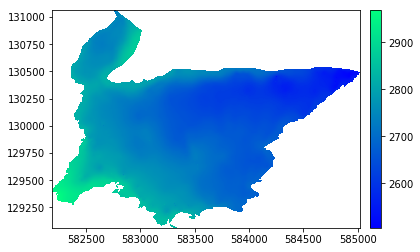

In [205]:
imgplt.drawImage2D(all_sim_me,cmap='winter')
#plt.scatter(hd_MNT.x(),hd_MNT.y(),s=5)
#plt.scatter(hd_GPR.x(),hd_GPR.y(),s=5)

In [192]:
meanAlt_values.shape

(1, 1, 1000, 1413)

In [197]:
#We can compute the difference of the value along an axis 
#in order to identify geomorphological features:
meanAlt_values = np.copy(all_sim_me.val)
diffAlt_values = np.diff(meanAlt_values[0,0])
print('Min diff value is {}, max diff value is {} and mean diff value is {}.'.format(str(np.nanmin(diffAlt_values)), 
                                                                                     str(np.nanmax(diffAlt_values)),
                                                                                     str(np.nanmean(diffAlt_values))))

Min diff value is -57.04998700357419, max diff value is 47.54901463202623 and mean diff value is -0.18328310263817668.


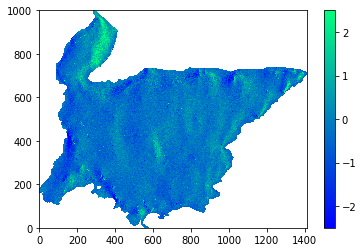

In [199]:
plt.pcolor(diffAlt_values, vmax=2.5, vmin=-2.5,cmap='winter')
plt.colorbar()

### Kriging

#### Data Preparation

In [3]:
from geone import grf
import krigeage as kg

In [67]:
#Hd with GPR and MNT
hd_x   = np.concatenate((hd_GPR.x(),hd_MNT.x()))
hd_y   = np.concatenate((hd_GPR.y(),hd_MNT.y()))
hd_val = np.concatenate((hd_GPR.val[3],hd_MNT.val[3]))
hd_x.shape,hd_y.shape,hd_val.shape

((9611,), (9611,), (9611,))

In [222]:
#Hd only compose of GPR data
hd_x   = hd_GPR.x()
hd_y   = hd_GPR.y()
hd_val = hd_GPR.val[3]
hd_x.shape,hd_y.shape,hd_val.shape

((2493,), (2493,), (2493,))

#### Remove the trend of the data

In [69]:
#we want to interpolate the trend value and substracte it to the data set
from sklearn.linear_model import LinearRegression as lr 

In [223]:
#Prepare the data for the interpolation
#X the coordinnate, and Y the values to interpolate
X = [[x,y] for x, y in zip(hd_x,hd_y)]
X = np.array(X)
Y = np.array(hd_val)
X, Y

(array([[582751.0295, 130232.9438],
        [582762.1221, 130227.2151],
        [582772.2306, 130220.0625],
        ...,
        [582636.1446, 130015.6996],
        [582585.997 , 129788.0727],
        [582666.204 , 130133.4421]]),
 array([2743.706, 2743.253, 2740.084, ..., 2750.499, 2779.69 , 2756.229]))

In [225]:
#Linear regression model
regLinear = lr().fit(X,Y)
regLinear.score(X,Y), regLinear.coef_

(0.9269371047058697, array([-0.1061954 , -0.06680665]))

In [226]:
#We substract the interpolate value to the data value
trend_val = regLinear.predict(X)
Y_noTrend = Y - trend_val

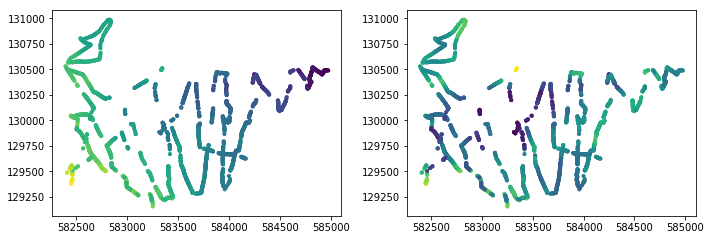

In [227]:
fig  = plt.subplots(1,2,figsize=(10,10))
plt.subplot(1,2,1)
plt.scatter(X[:,0],X[:,1],s=10,c=Y)
plt.axis('scaled')
plt.subplot(1,2,2)
plt.scatter(X[:,0],X[:,1],s=10,c=Y_noTrend)
plt.axis('scaled')
plt.tight_layout()

#### Semi-variogramm

/home/valentin/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:3215: MatplotlibDeprecationWarning: 
The `xmin` argument was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use `left` instead.
  alternative='`left`', obj_type='argument')
/home/valentin/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:3604: MatplotlibDeprecationWarning: 
The `ymin` argument was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use `bottom` instead.
  alternative='`bottom`', obj_type='argument')


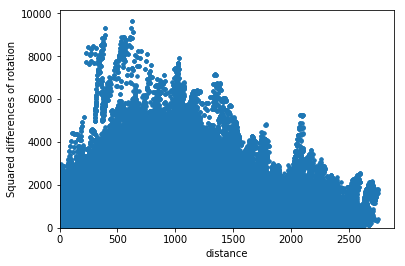

In [94]:
#Variogramme cloud
hc,gc = kg.cloud(X[:,0],X[:,1],Y_noTrend)
plt.scatter(hc, gc, s=10)
plt.xlabel('distance')
plt.ylabel('Squared differences of rotation')
plt.xlim(xmin=0)
plt.ylim(ymin=0)
plt.show()

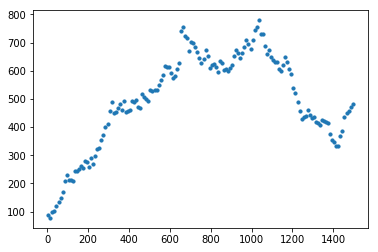

In [228]:
#Experimental variogram
he, ge = kg.experimental(hc,gc,10,150)
plt.scatter(he,ge,s=10)
plt.show()

/home/valentin/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:3215: MatplotlibDeprecationWarning: 
The `xmin` argument was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use `left` instead.
  alternative='`left`', obj_type='argument')
/home/valentin/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:3221: MatplotlibDeprecationWarning: 
The `xmax` argument was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use `right` instead.
  alternative='`right`', obj_type='argument')
/home/valentin/anaconda3/lib/python3.7/site-packages/matplotlib/axes/_base.py:3604: MatplotlibDeprecationWarning: 
The `ymin` argument was deprecated in Matplotlib 3.0 and will be removed in 3.2. Use `bottom` instead.
  alternative='`bottom`', obj_type='argument')


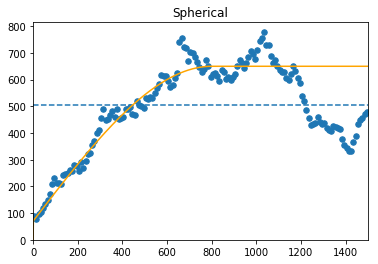

In [229]:
#Fit the experimental model
lag, nlag      = 10, 150
sillE, rangeE  = 580 , 800
x   = np.linspace(0, nlag * lag, 1000)
y_1 = kg.spherical(x, sillE, rangeE)
y_2 = kg.nugget(x, 70)
y   = y_1 + y_2
plt.scatter(he, ge, s=30)
variance = np.var(Y_noTrend)
plt.axhline(variance, linestyle='--')
plt.xlim(xmin=0, xmax=lag * nlag)
plt.ylim(ymin=0)
plt.title('Spherical')
plt.plot(x, y,color='orange')
plt.show()

#### Krige map

##### With grf function

In [137]:
#Define the model
import geone.covModel as gcm

cov_model = gcm.CovModel2D(elem=[
    ('spherical', {'w':580, 'r':[800,800]}),
    ('nugget',{'w':70})  # elementary contribution
    ], alpha=0, name='model_2D')

cov_fun   = cov_model.func()
vario_fun = cov_model.vario_func()

In [138]:
#Create the grid
layer     = mask_2m
dimension = [layer.nx,layer.ny]
spacing   = [layer.sx,layer.sy]
origin    = [layer.ox,layer.oy]
extension = [grf.extension_min(r, n, s) for r, n, s in zip(cov_model.rxy(), dimension, spacing)]

In [160]:
#We need to remove the points set that share the same grid coordinnates :
#Two possibility: bourrin (csv to point set/ to image/ to point set/ to csv) 
# or with coordinate and grid assignation and mean over data

In [133]:
#Bourrin:
ptVar = [X[:,0], X[:,1], [0]*len(X[:,0]), Y_noTrend]
dataPoints = img.PointSet(len(X),4,ptVar,['X','Y','Z','badRock'],'hd')
imgPoints = img.pointSetToImage(dataPoints,mask_2m.nx, mask_2m.ny, 1,
                               mask_2m.sx,mask_2m.sy,1,mask_2m.ox,
                                mask_2m.oy,0)
pointSetExport = img.imageToPointSet(imgPoints)
pointSetExport.val[3] = np.nan_to_num(pointSetExport.val[3])
position  = pointSetExport.val[3]!=0
x_toKrige = pointSetExport.val[0][position]
y_toKrige = pointSetExport.val[1][position]
Y_noTrend = pointSetExport.val[3][position]
X = [[x,y] for x,y in zip(x_toKrige,y_toKrige)]

In [ ]:
#Smart with mean(TO DO):
ptVar      = [X[:,0], X[:,1], [0]*len(X[:,0]), y_noTrend]
dataPoints = img.PointSet(len(X),4,ptVar,['X','Y','Z','badRock'],'hd')
imgPoints  = img.pointSetToImage(dataPoints,mask_2m.nx, mask_2m.ny, 1,
                               mask_2m.sx,mask_2m.sy,1,mask_2m.ox,
                                mask_2m.oy,0)


In [139]:
#Krig without krig_var (fast)
krig_2 = grf.krige2D(X, Y_noTrend,cov_fun, dimension, 
                                spacing, origin,
                                conditioningMethod=2,measureErrVar=0,
                                computeKrigSD=False,extensionMin=extension)

KRIGE2D: Computing circulant embedding...
KRIGE2D: Embedding dimension: 2048 x 2048
KRIGE2D: Computing FFT of circulant matrix...
KRIGE2D: Computing covariance matrix (rAA) for conditioning locations...
KRIGE2D: Computing index in the embedding grid for non-conditioning / conditioning locations...
KRIGE2D: computing kriging estimates...


In [64]:
#Krig without krig_var (fast)
krig_2, krig_2_var = grf.krige2D(X, Y_no_trend, 
                                cov_fun, dimension, 
                                spacing, origin,
                                conditioningMethod=2,measureErrVar=0,
                                computeKrigSD=True,extensionMin=extension)

KRIGE2D: Computing circulant embedding...
KRIGE2D: Embedding dimension: 2048 x 2048
KRIGE2D: Computing FFT of circulant matrix...
KRIGE2D: Computing covariance matrix (rAA) for conditioning locations...
KRIGE2D: Computing index in the embedding grid for non-conditioning / conditioning locations...
KRIGE2D: computing kriging estimates...
KRIGE2D: computing kriging standard deviation ...


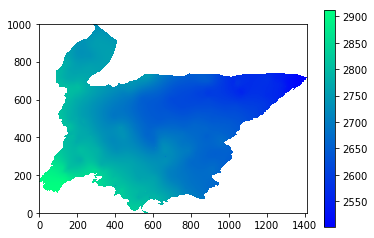

In [207]:
im_plot = plt.imshow(Y_trend, origin='lower',interpolation='none',cmap='winter')
plt.colorbar()

In [157]:
#Interpolate the trend values and additionne them to the krig values
X_grid    = [[x,y] for x,y in zip(xv.reshape((1413*1000)), yv.reshape((1413*1000)))]
X_grid    = np.array(X_grid)
trend_val = regLinear.predict(X_grid)
Y_trend   = krig_2.reshape((1000*1413)) + trend_val
Y_trend   = Y_trend.reshape((1000,1413))

In [141]:
#Remove the value outside the mask
for i in range(krig_2.shape[0]):
    for j in range(krig_2.shape[1]):
        if str(mask_2m.val[0,0,i,j])=='nan':
            krig_2[i,j]='nan'

In [200]:
#Compute the diff in direction to observe geomorphological shape
Y_trend_diff = np.diff(Y_trend)
np.nanmin(Y_trend_diff), np.nanmax(Y_trend_diff), np.nanmean(Y_trend_diff)

(-47.98639108643647, 47.707395378676665, -0.2074651724426729)

In [174]:

x = np.array([[1, 3, 6, 10], [0, 5, 6, 8], [1,1,1,1]])
np.diff(x,axis=0)


array([[-1,  2,  0, -2],
       [ 1, -4, -5, -7]])

In [ ]:
#Transform to img

In [ ]:
#Save to pickle
with open('krig_2.pickle','bw') as file:
    pickle.dump(krig_2,file,pickle.HIGHEST_PROTOCOL)

In [214]:
diff_interpolation = all_sim_me.val[0,0]-Y_trend


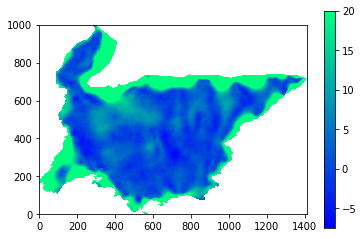

In [216]:
im_plot = plt.imshow(diff_interpolation, origin='lower',interpolation='none',cmap='winter',vmax=20)
plt.colorbar()

### Gaussian simulation

### Brouillon

In [38]:
dem_2m.nx,dem_2m.ny

(2553, 1791)

In [40]:
dem_2m.ox,dem_2m.oy

(580464.0, 127668.0)

In [39]:
all_sim_std.nx, all_sim_std.ny

(1413, 1000)

In [41]:
all_sim_std.ox, all_sim_std.oy

(582190.2921, 129062.3012)